In [123]:
from llama_index.core import SimpleDirectoryReader, VectorStoreIndex, StorageContext, Settings, Document
from llama_index.vector_stores.qdrant import QdrantVectorStore
from llama_index.core.node_parser import SentenceSplitter, TokenTextSplitter, SemanticSplitterNodeParser
from transformers import AutoTokenizer
import tqdm
from qdrant_client import QdrantClient, AsyncQdrantClient
from llama_index.vector_stores.qdrant import QdrantVectorStore
from llama_index.embeddings.openai_like import OpenAILikeEmbedding
from pathlib import Path
import numpy as np
import pandas as pd
from typing import Dict, List, Any
import asyncio
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import json
import logging
logging.getLogger("httpx").setLevel(logging.WARNING)

In [124]:
COLLECT_NAME = "wb"
EMBED_MODEL_NAME = "Qwen/Qwen3-Embedding-0.6B"
CHUNK_SIZE = 512 # в токенах
CHUNK_OVERLAP = np.linspace(75, 400, 10, dtype=int)
qwen_tokenizer = AutoTokenizer.from_pretrained(EMBED_MODEL_NAME)

In [125]:
np.linspace(75, 400, 10, dtype=int)

array([ 75, 111, 147, 183, 219, 255, 291, 327, 363, 400])

In [126]:
# local_data 
local_data = Path.cwd() / "../data"

In [127]:
reader = SimpleDirectoryReader(input_dir=local_data, required_exts=[".pdf"])
docs = reader.load_data()
print(len(docs))
assert len(docs) == 86, "ОШИБКА, должно быть 86"

# full_text = "\n\n".join([d.text for d in docs])
# all_docs = Document(text=full_text)

86


In [128]:
# Сначала проставляем page_label ВСЕМ документам (до удаления!),
# чтобы номер страницы соответствовал реальному номеру в PDF
for i, doc in enumerate(docs):
    doc.metadata["page_label"] = i + 1

# Удаляем пустые, сохраняя правильные page_label
empty_indices = [i for i, doc in enumerate(docs) if len(doc.text) == 0]
print(f"Пустые страницы (реальные номера): {[docs[i].metadata['page_label'] for i in empty_indices]}")
for i in sorted(empty_indices, reverse=True):  # с конца, чтобы индексы не сдвигались
    docs.pop(i)

print(f"Документов после очистки: {len(docs)}")

Пустые страницы (реальные номера): [34, 86]
Документов после очистки: 84


In [129]:
def build_text_with_page_map(docs):
    """
    Объединяет документы в один текст и строит карту: 
    символьная позиция → номер страницы.
    
    Returns:
        full_text (str): объединённый текст всех документов
        page_ranges (list): [(start_char, end_char, page_label_str), ...]
    """
    full_text = ""
    page_ranges = []
    
    for doc in docs:
        start = len(full_text)
        full_text += doc.text + "\n\n"
        end = len(full_text)
        page_label = str(doc.metadata["page_label"])
        page_ranges.append((start, end, page_label))
    
    return full_text, page_ranges


# Использование:
full_text, page_ranges = build_text_with_page_map(docs)
all_docs = Document(text=full_text)

In [130]:
def get_pages_for_chunk(chunk_start, chunk_end, page_ranges):
    """
    По символьным позициям чанка определяет, к каким страницам он относится.
    Чанк «принадлежит» странице, если хотя бы часть его текста попала на эту страницу.
    """
    pages = []
    for pr_start, pr_end, page_label in page_ranges:
        if chunk_start < pr_end and chunk_end > pr_start:
            pages.append(page_label)
    return pages

In [131]:
def enrich_nodes_with_page_info(nodes, full_text, page_ranges):
    """
    Привязка страниц к чанкам через поиск позиции чанка в исходном тексте.
    Работает точно, без маркеров.
    """
    search_start = 0
    
    for node in nodes:
        idx = full_text.find(node.text, search_start)
        if idx == -1:
            # fallback: ищем с начала (может понадобиться из-за overlap)
            idx = full_text.find(node.text)
        
        if idx != -1:
            chunk_start = idx
            chunk_end = idx + len(node.text)
            node.metadata["pages_covered"] = get_pages_for_chunk(
                chunk_start, chunk_end, page_ranges
            )
            # Не сдвигаем на chunk_end, а на idx, из-за overlap
            search_start = idx
        else:
            # Крайне редкий случай, логируем для отладки
            print(f"⚠️ Чанк не найден в тексте: {node.text[:80]}...")
            node.metadata["pages_covered"] = []
    
    return nodes

In [132]:
def get_chunking(chunk_overlap, docs, full_text, page_ranges):
    splitter = TokenTextSplitter(chunk_size=CHUNK_SIZE,
                                 chunk_overlap=chunk_overlap,
                                 tokenizer=qwen_tokenizer.encode)
    nodes = splitter.get_nodes_from_documents([docs])
    nodes = enrich_nodes_with_page_info(nodes, full_text, page_ranges)
    return nodes, splitter

In [133]:
def create_collect(chunk_overlap, docs, full_text, page_ranges):
    client = QdrantClient(url="http://127.0.0.1:6333")

    col_name = f"{COLLECT_NAME}_token_spl_best_{CHUNK_SIZE}_{chunk_overlap}"

    if client.collection_exists(collection_name=col_name):
        client.delete_collection(collection_name=col_name)

    nodes, splitter = get_chunking(chunk_overlap, docs, full_text, page_ranges)

    vector_store = QdrantVectorStore(collection_name=col_name,
                                     client=client)
 
    storage_context = StorageContext.from_defaults(vector_store=vector_store)

    index = VectorStoreIndex(
        nodes=nodes,
        storage_context=storage_context,
        # show_progress=True
    )

    client.update_collection(collection_name=col_name,
                             metadata={"chunk_size": f"{splitter.chunk_size}",
                                       "chunk_overlap": f"{splitter.chunk_overlap}",
                                       "splitter": splitter.class_name(),
                                       "tokenizer": EMBED_MODEL_NAME,
                                       "docs": docs
                                        })


    print(f"Коллекция {col_name} успешно создана и проиндексирована")

In [134]:
Settings.embed_model = OpenAILikeEmbedding(
    model_name="qwen3-embed",                    
    api_base="http://localhost:8081/v1",                      
)

try:
    req = requests.get(url="http://localhost:8081/health")
    if req.status_code == 200:
        print("✅ vLLM успешно подключён к LlamaIndex")
except Exception as e:
    print(f"Ошибка {e}")

for chunk_overlap in tqdm.tqdm(CHUNK_OVERLAP):
    create_collect(chunk_overlap, all_docs, full_text, page_ranges)

✅ vLLM успешно подключён к LlamaIndex


 10%|█         | 1/10 [00:03<00:30,  3.41s/it]

Коллекция wb_token_spl_best_512_75 успешно создана и проиндексирована


 20%|██        | 2/10 [00:06<00:27,  3.46s/it]

Коллекция wb_token_spl_best_512_111 успешно создана и проиндексирована


...

Коллекция wb_token_spl_best_512_327 успешно создана и проиндексирована


 90%|█████████ | 9/10 [00:41<00:05,  5.54s/it]

Коллекция wb_token_spl_best_512_363 успешно создана и проиндексирована


100%|██████████| 10/10 [00:50<00:00,  5.02s/it]

Коллекция wb_token_spl_best_512_400 успешно создана и проиндексирована


In [135]:
titles_collects = [f"{COLLECT_NAME}_token_spl_best_{CHUNK_SIZE}_{chunk_overlap}" for chunk_overlap in CHUNK_OVERLAP]
# titles_collects

In [136]:
def calculate_metrics(
    retrieved_nodes: List[Any],
    relevant_pages: List[str] | set,
    k: int = 5
) -> Dict[str, float]:
    """
    Подсчёт метрик качества поиска для ОДНОГО запроса.
    
    Метрики:
    - precision@k: доля релевантных чанков среди top-k
    - recall@k: доля найденных релевантных страниц
    - f1@k: гармоническое среднее precision и recall
    - hit_rate@k: 1.0 если хотя бы один чанк в top-k релевантен, иначе 0.0
    - mrr@k: 1 / ранг первого релевантного чанка (0.0 если не найден)
    """
    relevant_pages = set(relevant_pages)
    
    retrieved_pages = set()
    relevant_chunks_count = 0
    first_relevant_rank = 0  # для MRR
    
    for i, node in enumerate(retrieved_nodes[:k]):
        chunk_pages = set(node.metadata.get("pages_covered", []))
        overlap = chunk_pages & relevant_pages
        
        retrieved_pages.update(chunk_pages)
        
        if overlap:
            relevant_chunks_count += 1
            if first_relevant_rank == 0:
                first_relevant_rank = i + 1  # ранг (начиная с 1)
    
    # Precision: доля релевантных чанков в top-k
    precision = relevant_chunks_count / k if k > 0 else 0.0
    
    # Recall: доля релевантных страниц, которые удалось найти
    recall = (
        len(retrieved_pages & relevant_pages) / len(relevant_pages)
        if relevant_pages else 0.0
    )
    
    # F1
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0 else 0.0
    )
    
    # Hit Rate (бинарный): нашёлся ли хотя бы 1 релевантный чанк
    hit_rate = 1.0 if relevant_chunks_count > 0 else 0.0
    
    # MRR: обратный ранг первого релевантного чанка
    mrr = 1.0 / first_relevant_rank if first_relevant_rank > 0 else 0.0
    
    return {
        "precision@k": round(precision, 4),
        "recall@k": round(recall, 4),
        "f1@k": round(f1, 4),
        "hit_rate@k": round(hit_rate, 4),
        "mrr@k": round(mrr, 4),
    }

In [137]:
async def evaluate_collection(
    index,
    eval_data: List[Dict],
    top_k: int = 5,
    retrieval_k: int = 10
) -> pd.Series:
    retriever = index.as_retriever(similarity_top_k=retrieval_k)
    
    tasks = [retriever.aretrieve(item["query"]) for item in eval_data]
    all_retrieved_nodes = await asyncio.gather(*tasks)
    
    all_metrics = []
    for nodes, item in zip(all_retrieved_nodes, eval_data):
        metrics = calculate_metrics(nodes, item["relevant_pages"], k=top_k)
        all_metrics.append(metrics)
    
    df = pd.DataFrame(all_metrics)
    avg = df.mean().round(4)
    return avg

In [138]:
client = AsyncQdrantClient(url="http://127.0.0.1:6333",
                           prefer_grpc=True)
# EMBED_MODEL_NAME = "Qwen/Qwen3-Embedding-0.6B"
# COLL_NAME = "wb_token_spl_550_75"
# collect = client.get_collection(collection_name=COLL_NAME)

In [139]:
async def get_results(titles, eval_data):
    all_results = []

    for title in titles:
        # ВАЖНО: используем aclient для асинхронной работы
        vector_store = QdrantVectorStore(collection_name=title, aclient=client)
        index = VectorStoreIndex.from_vector_store(vector_store=vector_store)

        for k in [1, 2, 3, 4, 5, 10]:
            print(f"Эксперимент: {title}, k={k}")
            
            # Ожидаем выполнения асинхронной оценки
            avg_metrics = await evaluate_collection(index, eval_data, top_k=k, retrieval_k=12)
            res = await client.get_collection(title)
            
            res_dict = avg_metrics.to_dict()
            res_dict['collection'] = title
            res_dict['k'] = k
            res_dict["chunk_size"] = res.config.metadata["chunk_size"]
            res_dict["overlap"] = res.config.metadata["chunk_overlap"]
            all_results.append(res_dict)

    df_results = pd.DataFrame(all_results)
    df_results.to_csv("../results/rag_overlap_results.csv", index=False)
    return df_results

In [140]:
res = await client.get_collection("wb_token_spl_best_500_255")
res.config.metadata

{'splitter': 'TokenTextSplitter',
 'chunk_size': '500',
 'chunk_overlap': '255',
 'tokenizer': 'Qwen/Qwen3-Embedding-0.6B',
 'docs': {'class_name': 'Document',
  'text': 'ОФЕРТАоб оказании услуг в ПВЗ\n1. Термины и определения\n1.1. Активация ПВЗ — процесс, в результате которого ПВЗ Исполнителя становится действующим, моментом\nАктивации ПВЗ признается получение Исполнителем подтверждения от Заказчика о возможной Активации в\nсоответствии с п. 3.2 Договора.\n1.2. Аудит ПВЗ — действия, совершаемые различными способами Заказчиком по проверке соответствия ПВЗ\nИсполнителя в части соблюдения Регламента состояния ПВЗ.\n1.3. Баланс — сведения, отраженные в Личном кабинете Исполнителя о начисленном Исполнителю\nвознаграждении за оказанные Услуги, с учетом сумм неустоек (штрафов) и возмещаемых Исполнителем\nзадолженностей, а также с учетом суммы иных обязательств Исполнителя перед Заказчиком.\n1.4. Блокировка ПВЗ — частичное ограничение функционала Портала в отношении ПВЗ, применяемое в порядк

In [141]:
eval_full_data = []
with open("../context/docs_questions_qwen3_14b_awq.jsonl", "r") as f:
    lines = f.readlines()
    for line in lines:
        line = json.loads(line)
        eval_full_data.append({
            "query": list(line.values())[0]["simple"],
            "relevant_pages": list(line.keys())[0].split("_")[1:]
        })
        eval_full_data.append({
            "query": list(line.values())[0]["medium"],
            "relevant_pages": list(line.keys())[0].split("_")[1:]
        })
        eval_full_data.append({
            "query": list(line.values())[0]["complex"],
            "relevant_pages": list(line.keys())[0].split("_")[1:]
        })

In [142]:
await get_results(titles=titles_collects, eval_data=eval_full_data)

Эксперимент: wb_token_spl_best_512_75, k=1
Эксперимент: wb_token_spl_best_512_75, k=2
Эксперимент: wb_token_spl_best_512_75, k=3
Эксперимент: wb_token_spl_best_512_75, k=4
Эксперимент: wb_token_spl_best_512_75, k=5
Эксперимент: wb_token_spl_best_512_75, k=10
Эксперимент: wb_token_spl_best_512_111, k=1
Эксперимент: wb_token_spl_best_512_111, k=2
Эксперимент: wb_token_spl_best_512_111, k=3
Эксперимент: wb_token_spl_best_512_111, k=4
Эксперимент: wb_token_spl_best_512_111, k=5
Эксперимент: wb_token_spl_best_512_111, k=10
Эксперимент: wb_token_spl_best_512_147, k=1
Эксперимент: wb_token_spl_best_512_147, k=2
Эксперимент: wb_token_spl_best_512_147, k=3
Эксперимент: wb_token_spl_best_512_147, k=4
Эксперимент: wb_token_spl_best_512_147, k=5
Эксперимент: wb_token_spl_best_512_147, k=10
Эксперимент: wb_token_spl_best_512_183, k=1
Эксперимент: wb_token_spl_best_512_183, k=2
Эксперимент: wb_token_spl_best_512_183, k=3
Эксперимент: wb_token_spl_best_512_183, k=4
Эксперимент: wb_token_spl_best_512_

,precision@k,recall@k,f1@k,hit_rate@k,mrr@k,collection,k,chunk_size,overlap
0,0.6486,0.6486,0.6486,0.6486,0.6486,wb_token_spl_best_512_75,1,512,75
1,0.5450,0.8108,0.6337,0.8108,0.7297,wb_token_spl_best_512_75,2,512,75
2,0.4655,0.8559,0.5788,0.8559,0.7447,wb_token_spl_best_512_75,3,512,75
3,0.4088,0.8964,0.5368,0.8964,0.7549,wb_token_spl_best_512_75,4,512,75
4,0.3568,0.9099,0.4896,0.9099,0.7576,wb_token_spl_best_512_75,5,512,75
5,0.2261,0.9414,0.3514,0.9414,0.7623,wb_token_spl_best_512_75,10,512,75
6,0.6532,0.6532,0.6532,0.6532,0.6532,wb_token_spl_best_512_111,1,512,111
7,0.5631,0.7973,0.6412,0.7973,0.7252,wb_token_spl_best_512_111,2,512,111
8,0.4760,0.8378,0.5833,0.8378,0.7387,wb_token_spl_best_512_111,3,512,111
9,0.4155,0.8874,0.5434,0.8874,0.7511,wb_token_spl_best_512_111,4,512,111


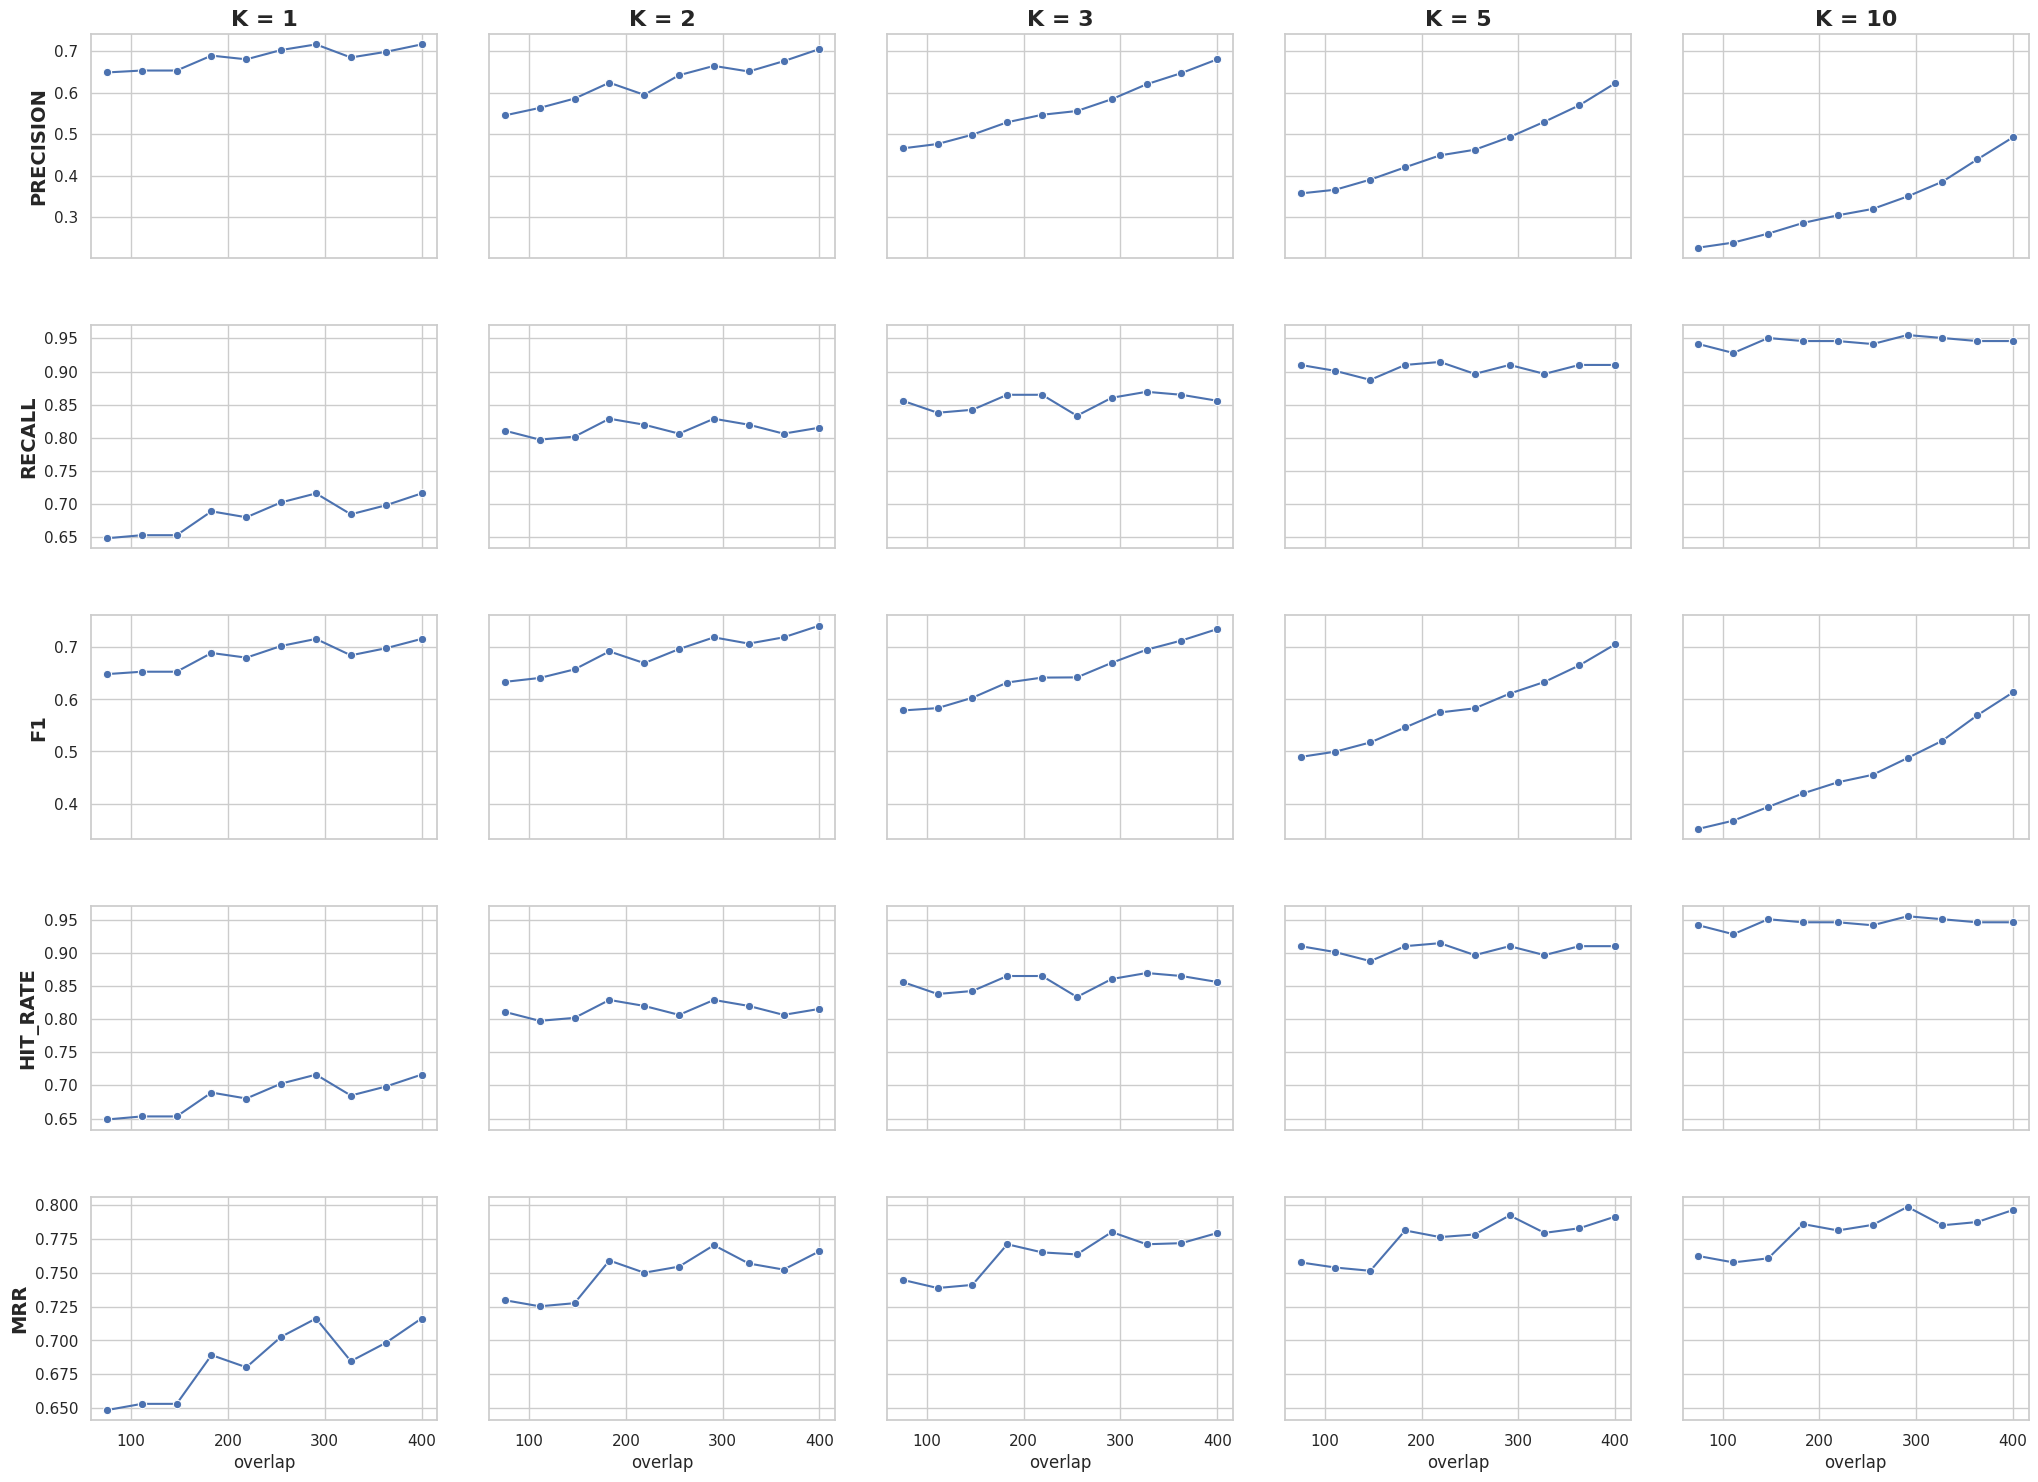

In [143]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
# 1. Загрузка и предобработка
df = pd.read_csv("../results/rag_overlap_results.csv")

# def extract_params(row):
#     # Ищем числа в формате ..._size_overlap
#     match = re.search(r'(\d+)_(\d+)$', row['collection'])
#     if match:
#         return int(match.group(1)), int(match.group(2))
#     return None, None

# df['chunk_size'], df['overlap'] = zip(*df.apply(extract_params, axis=1))
df = df.dropna(subset=['chunk_size']).sort_values('chunk_size')

# 2. Настройка параметров сетки
metrics = ['precision@k', 'recall@k', 'f1@k', 'hit_rate@k', 'mrr@k']
k_values = [1, 2, 3, 5, 10] # 5 колонок, как заказывали

fig, axes = plt.subplots(len(metrics), len(k_values), 
                         figsize=(25, 18), 
                         sharex='col', 
                         sharey='row')

plt.subplots_adjust(hspace=0.3, wspace=0.15)

# 3. Цикл построения
for row_idx, metric in enumerate(metrics):
    for col_idx, k_val in enumerate(k_values):
        ax = axes[row_idx, col_idx]
        
        # Фильтруем данные для конкретного k
        subset = df[df['k'] == k_val]
        
        # Строим график: зависимость метрики от размера чанка
        # hue='overlap' позволит увидеть разные линии, если у вас несколько вариантов перекрытия
        sns.lineplot(
            data=subset, 
            x='overlap', 
            y=metric, 
            marker='o', 
            ax=ax,
            # hue='overlap',
            # palette='viridis'
        )
        
        # Убираем легенду из всех графиков, кроме одного (чтобы не дублировать)
        # if row_idx == 0 and col_idx == len(k_values)-1:
        #     ax.legend(title='Overlap', bbox_to_anchor=(1.05, 1))
        # else:
        #     ax.get_legend().remove() if ax.get_legend() else None

        # Подписи только для краев сетки для чистоты
        if row_idx == 0:
            ax.set_title(f'K = {k_val}', fontsize=16, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(metric.replace('@k', '').upper(), fontsize=14, fontweight='bold')
        else:
            ax.set_ylabel('')
            
        # ax.set_xlabel('Chunk Size' if row_idx == len(metrics)-1 else '')

# Сохранение
plt.savefig("../results/overlap_grid.png", dpi=300, bbox_inches='tight')
plt.show()